### Import libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load Data

In [15]:
df = pd.read_csv("../data/raw/german_credit_data.csv")

# Drop index column if present
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


### Basic Info

In [16]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.2+ KB


None

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


### Target Distribution

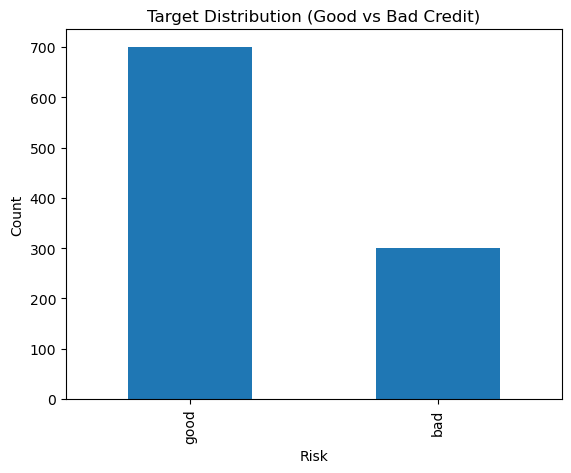

In [17]:
df['Risk'].value_counts().plot(kind='bar')
plt.title("Target Distribution (Good vs Bad Credit)")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.show()

### Missing Values

In [18]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

### Numerical Feature Analysis

#### Age Distribution

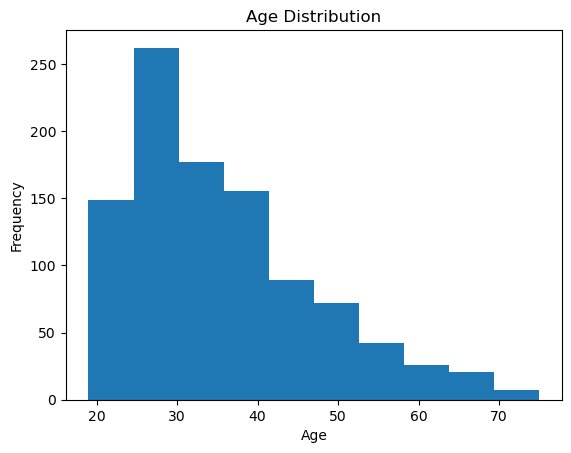

In [19]:
plt.hist(df['Age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

#### Credit Amount Distribution

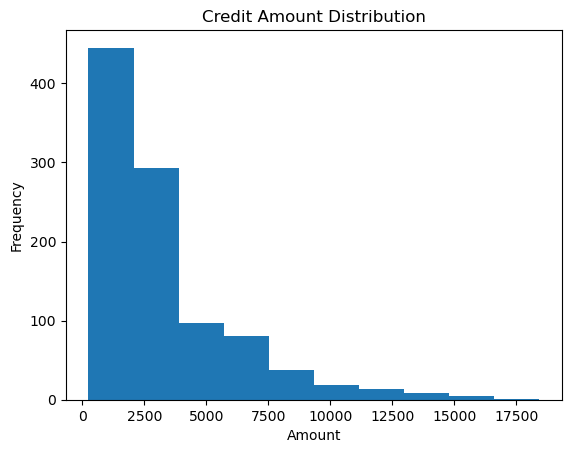

In [20]:
plt.hist(df['Credit amount'])
plt.title("Credit Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

#### Duration Distribution

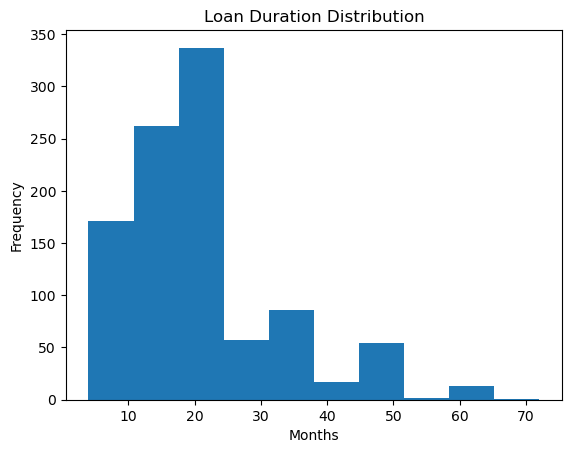

In [21]:
plt.hist(df['Duration'])
plt.title("Loan Duration Distribution")
plt.xlabel("Months")
plt.ylabel("Frequency")
plt.show()

### Default Rate by Category

#### Purpose vs Risk

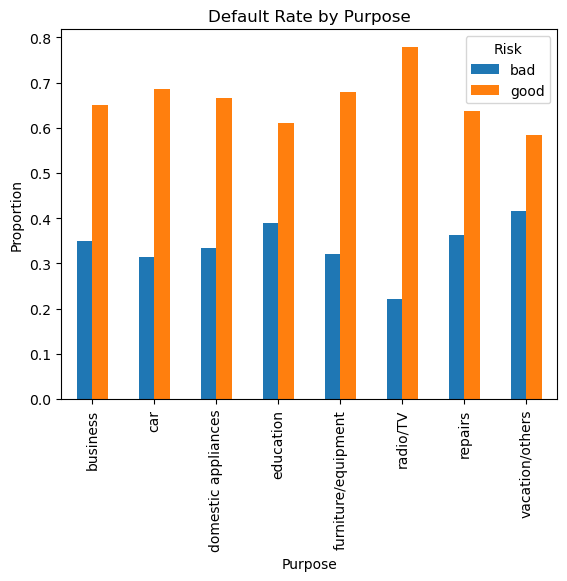

In [22]:
pd.crosstab(df['Purpose'], df['Risk'], normalize='index').plot(kind='bar')
plt.title("Default Rate by Purpose")
plt.ylabel("Proportion")
plt.show()

#### Housing vs Risk

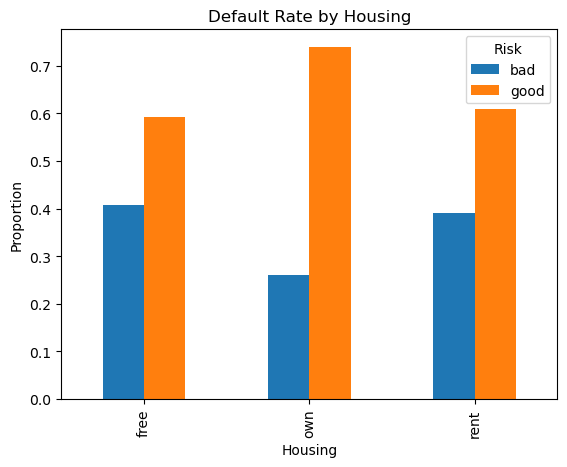

In [23]:
pd.crosstab(df['Housing'], df['Risk'], normalize='index').plot(kind='bar')
plt.title("Default Rate by Housing")
plt.ylabel("Proportion")
plt.show()

#### Saving Accounts vs Risk

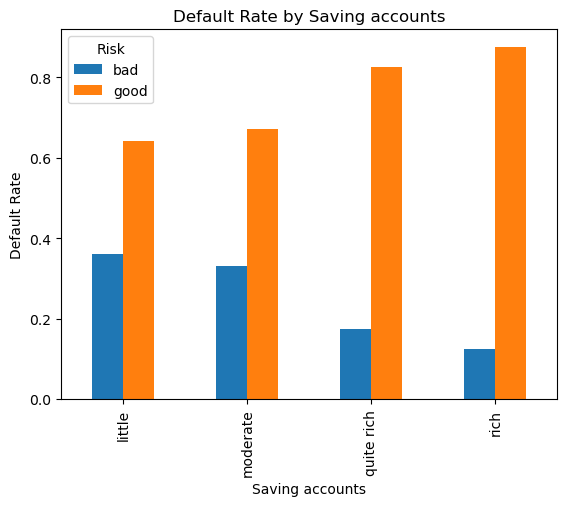

In [24]:
pd.crosstab(df['Saving accounts'], df['Risk'], normalize='index').plot(kind='bar')
plt.title("Default Rate by Saving accounts")
plt.ylabel("Default Rate")
plt.show()

### Age vs Risk

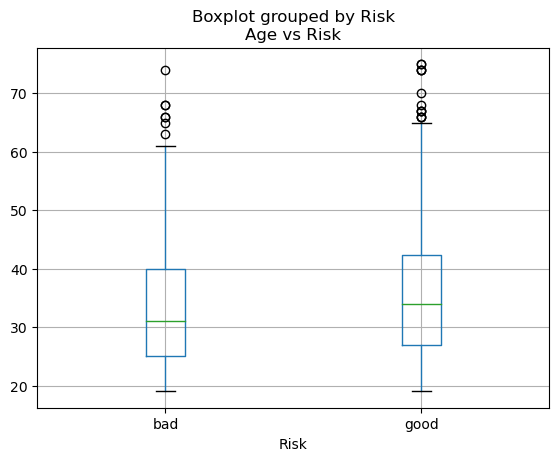

In [25]:
df.boxplot(column="Age", by="Risk")
plt.title("Age vs Risk")
plt.show()

### Correlation Analysis

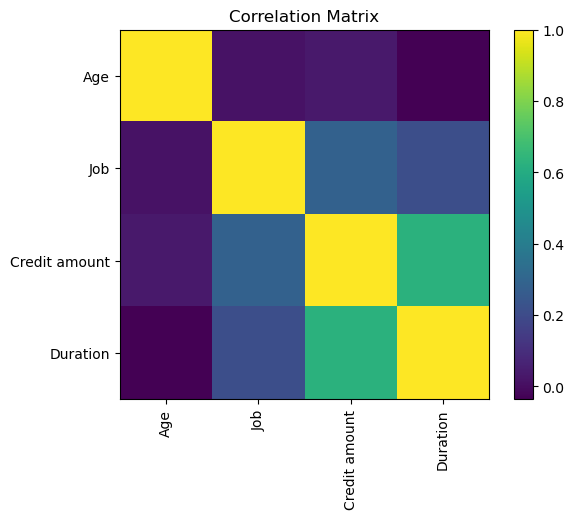

In [26]:
numeric_df = df.select_dtypes(include=[np.number])

corr = numeric_df.corr()

plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()